In [1]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

from src.physics import *
from src.models import *
from src.data import *
import numpy as np 

import torch
from torch.utils.data import IterableDataset, DataLoader
import wandb
from tqdm import tqdm 


## Testing Datasets

In [2]:
from src.physics.solver import ODEsolver
from scipy.stats import loguniform
 
import numpy as np 
 
import torch
from torch.utils.data import IterableDataset, DataLoader
 
# ------------------------------------------------
# Dataset Class
# ------------------------------------------------
 
class ODEIterableDataset(IterableDataset):
    """
    Iterable Dataset for on the fly ODE data
 
    Attributes:
        size         (integer)      : Desired size of the Dataset
        system_class  (object)      : ODE object with derivative method
        sampler       (object)      : Sampler Object with __call__ method
        t_span        (tuple)       : Tuple including initial and end integration times
        method        (String)      : solve_ivp numerical integration method
        log_sampling  (bool)        : If True, samples t uniformly in log space via loguniform
                                      Recommended for stiff ODEs with large t_span (e.g. Robertson)
        full_solution (String)      : Whether or not to output full solution or solution at time tf
        output_mask (integer array) : Allows the user to choose specific outputs 
 
    """
 
    def __init__(self, 
                 size,
                 system_class,
                 sampler, 
                 t_span,
                 method        = "RK45",
                 log_sampling  = False,
                 full_solution = False,
                 output_mask   = None):
 
        self.start      = 0
        self.end        = size
        self.size       = size
 
        self.system        = system_class
        self.sampler       = sampler
        self.t_span        = t_span
        self.method        = method
        self.log_sampling  = log_sampling
        self.full_solution = full_solution
        self.output_mask   = output_mask
 
        self.solver     = ODEsolver(system_class)
    
    def _sample_t(self, t0, tf):
        """Sample a random time point from t_span.
        
        If log_sampling is True, samples uniformly in log space using
        loguniform, ensuring equal coverage across all time decades.
        Requires t0 > 0.
 
        If log_sampling is False, samples uniformly in linear space.
        """
        if self.log_sampling:
            assert t0 > 0, "log_sampling requires t0 > 0 (t0 cannot be zero)"
            return loguniform.rvs(t0, tf)
        else:
            return np.random.uniform(t0, tf)
 
    def __iter__(self):
 
        # Handle Paralellism 
        worker_info = torch.utils.data.get_worker_info()
 
        if worker_info is None:
            iter_start = self.start
            iter_end   = self.end
 
        else:
            per_worker = int(np.ceil((self.end - self.start) / float(worker_info.num_workers)))
            worker_id  = worker_info.id
            iter_start = self.start + worker_id * per_worker
            iter_end   = min(iter_start + per_worker, self.end)
 
        for _ in range(iter_start, iter_end):
            
            # Sample Initial Conditions
            y0     = self.sampler(1)[0]
 
            # Sample Random integration end (linear or log space)
            t0, tf = self.t_span
            t      = self._sample_t(t0, tf)
 
            # Evaluate everywhere
            if self.full_solution:
                sol    = self.solver.solve((t0, tf),   
                                            y0, 
                                            self.method) 
                
                # Store full solution
                y_t    = sol.y[:]
                t_eval = sol.t[:]
                
            # Solve only until time t
            else:
                sol    = self.solver.solve((t0, t),     
                                            y0, 
                                            self.method,
                                            t_eval=[t]) # Only Returns solution at t
                
                # Store solution at time t
                y_t    = sol.y[:, -1]
                t_eval = sol.t[:] 
 
            # Select desired outputs 
            if self.output_mask is not None:
                y_t = y_t[self.output_mask]
                                        
            I = torch.tensor(y0,     dtype=torch.float32) # Initial Condition
            t = torch.tensor(t_eval, dtype=torch.float32) # output time 
            y = torch.tensor(y_t,    dtype=torch.float32) # y_I(t)
 
            yield I, t, y
    
    def __len__(self):
        return self.size




In [3]:
# Initialize Roberston Model
k1 = 4e-2
k2 = 3e7
k3 = 1e4
system = Robertson([k1, k2, k3])

# Initialize Sampler Object 
sampler = DirichletSampler(alpha=[1, 1, 1])

dataset    = ODEIterableDataset(size = 60,
                                system_class = system,
                                sampler      = sampler,
                                t_span       = (0, 100),
                                method       = "BDF",
                                output_mask  = np.array([0]))

batch_size = 7

def worker_init_fn(worker_id):
    base_seed = torch.initial_seed() % (2**32)
    np.random.seed(base_seed + worker_id)

dataloader = DataLoader(dataset, 
                        batch_size         = batch_size, 
                        num_workers        = 2,
                        drop_last          = False, 
                        persistent_workers = True)

all_batches = []
for I, t, y in dataloader:
    all_batches.append((I, t, y))
    # print(f"Batch shape: {I.shape}")

# print(f"Total batches: {len(all_batches)}")
# print(f"Total samples: {sum(b[0].shape[0] for b in all_batches)}")


In [4]:

import numpy as np
import torch
from torch.utils.data import DataLoader

# Initialize Robertson Model
k1 = 4e-2
k2 = 3e7
k3 = 1e4
system  = Robertson([k1, k2, k3])

# Initialize Sampler Object
sampler = DirichletSampler(alpha=[1, 1, 1])


# ---- Linear sampling (original) ----
dataset_linear    = ODEIterableDataset(size         = 60,
                                       system_class = system,
                                       sampler      = sampler,
                                       t_span       = (1e-5, 1e5),
                                       method       = "BDF",
                                       log_sampling = False,
                                       output_mask  = np.array([0]))

dataloader_linear = DataLoader(dataset_linear,
                               batch_size         = 7,
                               num_workers        = 2,
                               drop_last          = False,
                               persistent_workers = True)

# ---- Log sampling (new) ----
dataset_log       = ODEIterableDataset(size         = 100,
                                       system_class = system,
                                       sampler      = sampler,
                                       t_span       = (1e-10, 1e5),
                                       method       = "BDF",
                                       log_sampling = True,
                                       output_mask  = np.array([0]))

dataloader_log    = DataLoader(dataset_log,
                               batch_size         = 7,
                               num_workers        = 2,
                               drop_last          = False,
                               persistent_workers = True)



(array([12., 10., 13.,  7., 10.,  7., 12.,  9.,  8., 12.]),
 array([-9.95896053, -8.46441746, -6.96987438, -5.47533131, -3.98078823,
        -2.48624516, -0.99170208,  0.502841  ,  1.99738407,  3.49192715,
         4.98646975]),
 <BarContainer object of 10 artists>)

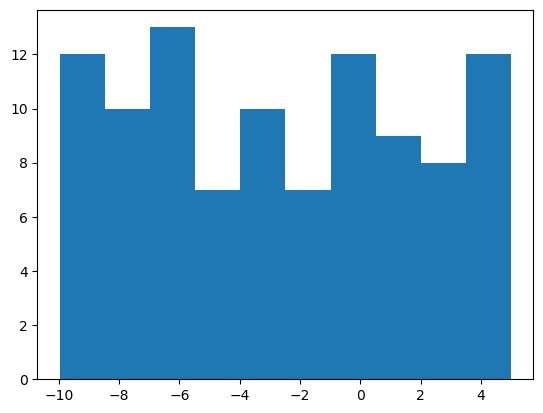

In [6]:
import matplotlib.pyplot as plt 

log_times = []
for I, t, y in dataloader_log:
    log_times.append(t.numpy().flatten())

t_all = np.concatenate(log_times) 

plt.hist(np.log10(t_all))

In [44]:
all_batches = []
for i, (I, t, y) in enumerate(dataloader):
    all_batches.append((I, t, y))
    print(f"--- Batch {i} ---")
    print(f"I:\n{I}")

print(f"\nTotal batches: {len(all_batches)}")
print(f"Total samples: {sum(b[0].shape[0] for b in all_batches)}")

--- Batch 0 ---
I:
tensor([[0.3598, 0.0457, 0.5945],
        [0.1820, 0.4866, 0.3314],
        [0.5648, 0.4195, 0.0157],
        [0.1138, 0.7842, 0.1020],
        [0.0447, 0.8652, 0.0902],
        [0.1451, 0.4818, 0.3731],
        [0.3654, 0.2481, 0.3865]])
--- Batch 1 ---
I:
tensor([[0.2001, 0.0315, 0.7684],
        [0.5789, 0.3283, 0.0928],
        [0.0805, 0.3861, 0.5333],
        [0.4925, 0.3129, 0.1946],
        [0.4325, 0.4885, 0.0790],
        [0.5797, 0.0679, 0.3524],
        [0.2639, 0.1090, 0.6272]])
--- Batch 2 ---
I:
tensor([[0.2434, 0.6037, 0.1529],
        [0.1591, 0.0055, 0.8355],
        [0.4012, 0.3654, 0.2333],
        [0.1632, 0.4378, 0.3990],
        [0.3680, 0.3426, 0.2894],
        [0.3196, 0.1216, 0.5588],
        [0.5374, 0.1942, 0.2684]])
--- Batch 3 ---
I:
tensor([[0.4619, 0.4524, 0.0857],
        [0.4985, 0.3145, 0.1870],
        [0.6713, 0.0828, 0.2459],
        [0.6694, 0.0718, 0.2588],
        [0.0342, 0.3826, 0.5832],
        [0.6514, 0.1461, 0.2025],
   

In [5]:

# Harmonic Oscillator 

# Define branch and trunk network parameters 
osc_input_size_b  = 2
osc_input_size_t  = 1
latent_output     = 10
osc_depth         = 4
osc_hidden_size   = 32

osc_output        = 1

# Initialize Branch and Trunk Nets 
osc_branch_net = General_MLP(input_size  = osc_input_size_b, 
                             output_size = latent_output,
                             depth       = osc_depth, 
                             hidden_size = osc_hidden_size, 
                             act         = nn.Tanh())

osc_trunk_net  = General_MLP(input_size  = osc_input_size_t, 
                             output_size = latent_output,
                             depth       = osc_depth, 
                             hidden_size = osc_hidden_size, 
                             act         = nn.Tanh())

# Initialize DeepONet 
osc_deepONet   = DeepONet(branch_net  = osc_branch_net, 
                          trunk_net   = osc_trunk_net,
                          output_size = osc_output)


In [6]:
pred = osc_deepONet(I_d, t_d)

In [7]:
# The shapes must match!
print(pred.size(), y_d.size())

torch.Size([10, 1]) torch.Size([10, 1])


In [8]:
loss_fn = torch.nn.MSELoss()
print(loss_fn(pred, y_d))


tensor(1.0580, grad_fn=<MseLossBackward0>)


## Testing Training Loops

In [9]:
def build_deeponet(cfg) -> nn.Module:
    

    # Retrieve Activation function
    activation = activation_map[cfg["activation"]]


    # Initialize Branch and Trunk Networks
    branch_net   = General_MLP(input_size  = cfg["input_size_b"], 
                               output_size = cfg["latent_size"],
                               depth       = cfg["depth"], 
                               hidden_size = cfg["hidden_size"], 
                               act         = activation)

    trunk_net    = General_MLP(input_size  = cfg["input_size_t"], 
                               output_size = cfg["latent_size"],
                               depth       = cfg["depth"], 
                               hidden_size = cfg["hidden_size"], 
                               act         = activation)
    
    return DeepONet(branch_net  = branch_net, 
                    trunk_net   = trunk_net, 
                    output_size = cfg["output_size"])


In [10]:
def build_dataloaders(train_dataset, val_dataset, cfg):
    
    train_loader = DataLoader(train_dataset, 
                              batch_size     = cfg["batch_size"],
                              num_workers    = cfg["num_workers"])

    val_loader   = DataLoader(val_dataset,   
                              batch_size     = cfg["batch_size"],
                              num_workers    = cfg["num_workers"])

    return train_loader, val_loader

In [11]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
        
    # Set Network to training mode 
    model.train()
    total_loss  = 0.0
    steps       = 0

    # Training Steps
    for batch in loader:

        inputs  = [x.to(device) for x in batch[:-1]]  # all but last = inputs
        targets = batch[-1].to(device)
        
        # Network forward Pass
        pred = model(*inputs) # Unpack inputs

        # Loss calculation
        loss = loss_fn(pred, targets)

        # Optimizer Steps
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        steps      += 1
    
    return total_loss / steps

def validate(model, loader, loss_fn, device):

    model.eval()
    total_loss  = 0.0
    steps       = 0

    for batch in loader:

        inputs  = [x.to(device) for x in batch[:-1]]  # all but last = inputs
        targets = batch[-1].to(device)
        
        # Network forward Pass
        pred = model(*inputs) # Unpack Inputs

        # Loss calculation
        loss = loss_fn(pred, targets)

        # Calculate Loss terms 
        total_loss   += loss.item()
        steps        += 1
    
    return total_loss / steps


In [ ]:
class Trainer():

    def __init__(self, model, train_dataset, val_dataset, optimizer, loss_fn, train_cfg, model_cfg):

        self.model         = model
        self.train_dataset = train_dataset
        self.val_dataset   = val_dataset
        self.loss_fn       = loss_fn
        self.optimizer     = optimizer
        self.train_cfg     = train_cfg
        self.model_cfg     = model_cfg
    
    def run(self, config=None):

        # Detect GPU 
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Check for Sweep Configuration
        if not config:
            config = {**self.train_cfg, **self.model_cfg, "device": str(device)}

        # Initialize Weights and Biases
        wandb.init(
            project = "PINNS-testing",
            config  = config,
            mode    = "online"
        )

        cfg = wandb.config

        # Initialize training and validation dataloaders 
        train_loader, val_loader = build_dataloaders(self.train_dataset, self.val_dataset, cfg)
        
        # Set model to device
        self.model = self.model.to(device)

        # Configure Optimizer
        self.optimizer = self.optimizer(self.model.parameters(), lr = cfg["learning_rate"])

        for epoch in tqdm(range(cfg['num_epochs']), desc="Training"):
            
            # Train epoch
            train_loss = train_one_epoch(self.model, train_loader, self.optimizer, self.loss_fn, device)

            # Validation Epoch
            val_loss   = validate(self.model, train_loader, self.loss_fn, device)

            # Weights And Biases Log 
            wandb.log({"train_loss": np.log(train_loss), "val_loss": np.log(val_loss)})
        
        # Save the Model weights 
        if cfg["Save_model"]: 
            torch.save(self.model.state_dict(), cfg["Save_directory"])
            wandb.save(cfg["Save_directory"]) 


In [13]:
activation_map = {
    "tanh"    : nn.Tanh(),
    "relu"    : nn.ReLU(),
    "sigmoid" : nn.Sigmoid(),
    "gelu"    : nn.GELU()
}

TRAIN_CONFIG = {

    "num_epochs"     : 100,
    "learning_rate"  : 0.0068741,
    "batch_size"     : 32,
    "num_workers"    : 2,
    "Save_model"     : False,
    "Save_directory" : None 

}


DEEPONET_CONFIG = {
    
    "hidden_size" : 32,
    "depth"       : 4,
    "latent_size" : 50,
    "input_size_b": 2,
    "input_size_t": 1,
    "output_size" : 1,
    "activation"  : "tanh",

}

In [14]:
k = 2.0
c = 0.5
system = harm_osc([k, c])

sampler = LatinHypercubeSampler(
    dimensions=2,
    lows      = [-1.0, -1.0],
    highs     = [1.0, 1.0]
)

train_dataset    = ODEIterableDataset(size = 1000,
                                      system_class = system,
                                      sampler      = sampler,
                                      t_span       = (0, 10),
                                      output_mask  = np.array([0]))

val_dataset      = ODEIterableDataset(size = 10,
                                      system_class = system,
                                      sampler      = sampler,
                                      t_span       = (0, 10),
                                      output_mask  = np.array([0]))



In [15]:
deeponet  = build_deeponet(DEEPONET_CONFIG)
optimizer = torch.optim.Adam
loss_fn   = torch.nn.MSELoss()

In [16]:
trainer   = Trainer(
    model         = deeponet,
    train_dataset = train_dataset, 
    val_dataset   = val_dataset, 
    optimizer     = optimizer,
    loss_fn       = loss_fn, 
    train_cfg     = TRAIN_CONFIG,
    model_cfg     = DEEPONET_CONFIG
)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, val_loader = build_dataloaders(train_dataset, val_dataset, TRAIN_CONFIG)

for batch in train_loader:
    inputs  = [x.to(device) for x in batch[:-1]]  # all but last = inputs
    targets = batch[-1].to(device)

In [18]:
pred = deeponet.to(device)(*inputs)

In [19]:
trainer.run()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/enricp/.netrc.
wandb: Currently logged in as: nikpursals to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training: 100%|██████████| 100/100 [04:22<00:00,  2.62s/it]


KeyError: 'Save_Model'

In [ ]:
import wandb
from tqdm import tqdm 


# -------------------------------------------------------------------------------
# 1. Training Function called by WANDB agent
# -------------------------------------------------------------------------------

def train(deeponet_arch, train_dataset, val_dataset, loss_function, config=None):

    # Detect GPU 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize WANDB config
    wandb.init(config  = config,
               project = "PINNS-testing",
               mode    = "online")

    wandb.config.update({"device": str(device)})
    
    cfg = wandb.config


    # Set config hyperparameters
    num_epochs         = cfg.num_epochs
    learning_rate      = cfg.learning_rate
    batch_size         = cfg.batch_size
    num_workers        = cfg.num_workers
    depth              = cfg.depth
    hidden_size        = cfg.hidden_size
    train_dataset_size = cfg.train_dataset_size
    val_dataset_size   = cfg.val_dataset_size
    osc_latent_size    = cfg.latent_size
    activation         = cfg.activation
    Save_model         = cfg.Save_model

    # Set DeepONet architecture
    input_size_b = deeponet_arch["input_size_b"]
    input_size_t = deeponet_arch["input_size_t"]
    latent_size  = deeponet_arch["latent_size"]
    output_size  = deeponet_arch["output_size"]


    # Activation function options 
    activation_map = {
        "tanh"    : nn.Tanh(),
        "relu"    : nn.ReLU(),
        "sigmoid" : nn.Sigmoid(),
        "gelu"    : nn.GELU()
    }

    activation = activation_map[activation]

    # Initialize dataloaders
    train_loader = DataLoader(dataset     = train_dataset, 
                              batch_size  = batch_size,
                              num_workers = num_workers)

    val_loader   = DataLoader(dataset     = val_dataset, 
                              batch_size  = batch_size,
                              num_workers = num_workers)
    
    # Initialize Branch and Trunk Nets 
    branch_net   = General_MLP(input_size  = input_size_b, 
                               output_size = latent_size,
                               depth       = depth, 
                               hidden_size = hidden_size, 
                               act         = activation)

    trunk_net    = General_MLP(input_size  = input_size_t, 
                               output_size = latent_size,
                               depth       = depth, 
                               hidden_size = hidden_size, 
                               act         = activation)

    # Initialize DeepONet 
    deepONet     = DeepONet(branch_net  = branch_net, 
                            trunk_net   = trunk_net,
                            output_size = output_size).to(device=device)
    
    # Initialize Adam Optimizer 
    optimizer = torch.optim.Adam(deepONet.parameters(), 
                                 lr=learning_rate)


    # -------------------------------------------------------------------------------
    # Training Loop
    # -------------------------------------------------------------------------------

    for epoch in tqdm(range(num_epochs), desc="Training"):

        # Set Network to training mode 
        deepONet.train()
        running_loss = 0.0
        num_steps    = 0.0

        # Training Steps
        for I, t, y in train_loader:

            # Use GPU, also note y[:, 0:1] because we are only extracting first output of solve_ivp
            I, t, y = I.to(device), t.to(device), y.to(device)
            
            # Network forward Pass
            pred = deepONet(I, t)

            # Loss calculation
            loss = loss_function(pred, y)

            # Optimizer Steps
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_steps  += 1
        
        train_loss = running_loss / num_steps # this can probably be changed to len(dataloader)

        # Validation Steps

        # Set model to evaluation mode
        deepONet.eval()
        running_loss   = 0.0
        num_steps      = 0.0

        # Validation Steps 
        with torch.no_grad():
            for I, t, y in val_loader:
                
                I, t, y = I.to(device), t.to(device), y.to(device)

                # Network Forward Pass
                pred = deepONet(I, t)

                # Loss calculation
                loss = loss_function(pred, y)

                running_loss += loss.item()
                num_steps += 1

        val_loss = running_loss / num_steps


        # Weights And Biases Log 
        wandb.log({"train_loss": np.log(train_loss), "val_loss": np.log(val_loss)})


    if Save_model:
        torch.save(deepONet.state_dict(), "weights/best_model.pth")
        wandb.save("weights/best_model.pth")  # syncs the file to W&B

In [ ]:
# Set Training Config

test_config={
    "num_epochs"        : 100,
    "learning_rate"     : 0.0068741,
    "batch_size"        : 32,
    "num_workers"       : 12,
    "hidden_size"       : 32,
    "depth"             : 4,
    "train_dataset_size": 1000,
    "val_dataset_size"  : 100,
    "latent_size"       : 50,
    "activation"        : "tanh",
    "Save_model"        : False
}

branch_input_size    = 2
trunk_input_size     = 1
latent_space_size    = 50
deeponet_output_size = 1

# Set up network Architecture 

deeponet_arch={
    "input_size_b" : branch_input_size ,
    "input_size_t" : trunk_input_size,
    "latent_size"  : latent_space_size,
    "output_size"  : deeponet_output_size
}


In [ ]:
k = 2.0
c = 0.5
system = harm_osc([k, c])

sampler = LatinHypercubeSampler(
    
    dimensions=2,
    lows      = [-1.0, -1.0],
    highs     = [1.0, 1.0]
)

train_dataset    = ODEIterableDataset(size = 1000,
                                      system_class = system,
                                      sampler      = sampler,
                                      t_span       = (0, 10),
                                      output_mask  = np.array([0]))

val_dataset      = ODEIterableDataset(size = 10,
                                      system_class = system,
                                      sampler      = sampler,
                                      t_span       = (0, 10),
                                      output_mask  = np.array([0]))


In [ ]:
"""loss_fn = torch.nn.MSELoss()

train(deeponet_arch = deeponet_arch, 
      train_dataset = train_dataset, 
      val_dataset   = val_dataset, 
      loss_function = loss_fn, 
      config        = test_config)


wandb.finish() """

'loss_fn = torch.nn.MSELoss()\n\ntrain(deeponet_arch = deeponet_arch, \n      train_dataset = train_dataset, \n      val_dataset   = val_dataset, \n      loss_function = loss_fn, \n      config        = test_config)\n\n\nwandb.finish() '